In [1]:
# pip install shared_utils

In [2]:
# Importing necessary package 
import pandas as pd 
import geopandas as gpd
pd.set_option('display.max_columns', None)
import os
import google.auth
import gcsfs
fs = gcsfs.GCSFileSystem()
import numpy as np

from scipy.stats import skew
from calitp_data_analysis.sql import get_engine
db_engine = get_engine()
credentials, project = google.auth.default()
fs = gcsfs.GCSFileSystem()
import matplotlib.pyplot as plt
import statsmodels.api as sm
from shapely.geometry import Point
from shapely import wkt
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
GCS_FILE_PATH = 'gs://calitp-analytics-data/data-analyses/ahsc_grant/ahsc_riderships/AHSC_2026'
with fs.open(f"{GCS_FILE_PATH}/stop_route_df.parquet", "rb") as f: 
    stop_route_df = gpd.read_parquet(f)

In [4]:
df_burbank = stop_route_df[stop_route_df['organization_name'] == "City of Burbank"]

In [5]:
rail_stops = [
    "Universal Redline Station",
    "NoHo Station",
    "Metrolink Station",
    "Hollywood Burbank Airport RITC"
]


df_burbank["has_rail_connection_dummy"] = 0

df_burbank.loc[
    df_burbank["stop_name"].isin(rail_stops),
    "has_rail_connection_dummy"
] = 1


X = df_burbank[[
    "total_pop_adj",
    "workers_with_no_car_adj",
    "total_seniors_adj",
    "inc_total_lowincome_adj",
    "has_rail_connection_dummy",
    "total_youth_adj"
]].copy()

X = sm.add_constant(X, has_constant="add")

/opt/conda/lib/python3.11/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [6]:
# y_log = np.log1p(df_burbank["average_daily_boardings"])

# model_ols = sm.OLS(y_log, X).fit()

# print(model_ols.summary())


model_fe = sm.GLM(
    df_burbank["average_daily_boardings"],
    X,
    family=sm.families.NegativeBinomial()
).fit()

print(model_fe.summary())

                    Generalized Linear Model Regression Results                    
Dep. Variable:     average_daily_boardings   No. Observations:                   45
Model:                                 GLM   Df Residuals:                       38
Model Family:             NegativeBinomial   Df Model:                            6
Link Function:                         Log   Scale:                          1.0000
Method:                               IRLS   Log-Likelihood:                -104.94
Date:                     Wed, 06 May 2026   Deviance:                       27.211
Time:                             20:04:08   Pearson chi2:                     21.2
No. Iterations:                         15   Pseudo R-squ. (CS):             0.5257
Covariance Type:                 nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------

/opt/conda/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


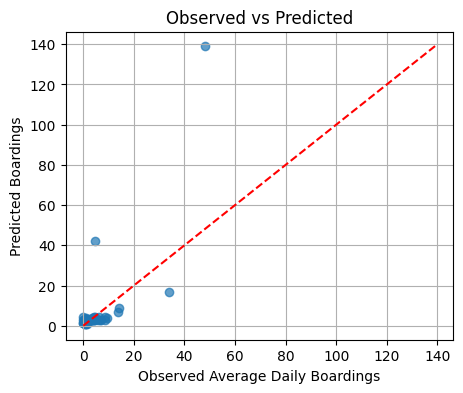

In [7]:
# observed values
observed = df_burbank["average_daily_boardings"]

# predicted values from fixed-effects model
predicted = model_fe.predict()

plt.figure(figsize=(5, 4))

plt.scatter(observed, predicted, alpha=0.7)

# perfect fit line
max_val = max(observed.max(), predicted.max())
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--")

plt.xlabel("Observed Average Daily Boardings")
plt.ylabel("Predicted Boardings")
plt.title("Observed vs Predicted")
plt.grid(True)

plt.show()

In [8]:
df = pd.read_csv("burbank_orange_new_stops.csv")
df["stop_dir_key"] = df["stop_name"] + " " + df["direction"]

In [9]:
manual_coords = {
"Hollywood & Jeffries eastbound": (34.18141305368438, -118.34903738211447),
"Hollywood & Victory Bl eastbound": (34.18508535157502, -118.34929119735641),
"Hollywood & Pacific eastbound": (34.18825119276962, -118.34886491064228),
"Hollywood & Valhalla eastbound": (34.19012427165374, -118.34916328937923),
"Hollywood & Thorton eastbound": (34.19656151035557, -118.34876716762236),
"Hollywood & Thorton westbound": (34.195980179882646, -118.34894014653726),
"New BUR terminal eastbound": (34.19359656711031, -118.35357055101639),
"New BUR terminal westbound": (34.19359656711031, -118.35357055101639),
"Winona / Ontario eastbound":  (34.199490557715684, -118.3443711434909),
"Winona / Ontario westbound":  (34.1992091874645, -118.34484346690523),
"Ontario & Thorton eastbound": (34.19593202043652, -118.34444331137956),
"Ontario & Thorton westbound": (34.19541510602419, -118.34460558501739),
"Empire & Ontario eastbound": (34.192108542580186, -118.3443394102755),
"Empire & Buena Vista eastbound": (34.19195822628478, -118.33787457476522),
"Empire & Valpreda eastbound": (34.19194945024493, -118.33285175184913),
"Empire & Valpreda westbound": (34.19179144771815, -118.33244032844016),
"Empire & Grismer eastbound":  (34.19175476406717, -118.32509312643347),
"Empire & Grismer westbound":  (34.19154206721876, -118.3254365921081),
"Amherst Dr / San Fernando eastbound": (34.19012800601128, -118.32086710181368),
"Amherst Dr / San Fernando westbound":  (34.189934438443714, -118.32176619076398),
"Glenoaks & Bethany eastbound":  (34.191647095345786, -118.31754103475315),
"Glenoaks & Bethany westbound":  (34.19168659607283, -118.3180498038794),
"Glenoaks & Fairmount eastbound": (34.18922976877985, -118.31426181767534),
"Glenoaks & Fairmount westbound": (34.18869054389077, -118.3139580922512),
"Glenoaks & Cypress eastbound":  (34.18708018484801, -118.31127153444093),
"Glenoaks & Cypress westbound":  (34.18677382226348, -118.31135025143384),
"Glenoaks & Magnolia eastbound": (34.18566039664216, -118.30935620418528),
"Glenoaks & Magnolia westbound": (34.1853950731641, -118.3094180753144),
"Glenoaks & Olive eastbound": (34.18338784687265, -118.30666291160377),
"Glenoaks & Olive westbound": (34.183750381812565, -118.30682928383196),
"Glenoaks & Verdugo eastbound": (34.1810536128531, -118.30348086446116),
"Glenoaks & Verdugo westbound": (34.18130060913145, -118.30290962506388),
"Glenoaks & Providencia eastbound": (34.17964641863243, -118.30103491619572),
"Glenoaks & Providencia westbound": (34.17927416886304, -118.30121771535951),
"Glenoaks / Alameda eastbound": (34.1769213295822, -118.29787237592716),
"Glenoaks / Alameda westbound": (34.17636895964169, -118.29776384800448),
"Alameda & San Fernando eastbound": (34.174365721132396, -118.29952381900989),
"Alameda & San Fernando westbound": (34.17430732460237, -118.30025580257688),
"Flower & Alameda eastbound": (34.17106795233713, -118.30268518471172),
"Flower & Alameda westbound": (34.17166407022795, -118.3032739880033)
}

In [10]:
df_blue = pd.read_csv("burbank_blue_new_stops.csv")
df_blue["stop_dir_key"] = df_blue ["stop_name"] + " " + df_blue ["direction"]

In [11]:
manual_coords_blue = {
    "Metrolink Station eastside terminal at Front St eastbound": (34.1928297181839, -118.35258351675843),
    "Metrolink Station eastside terminal at Front St westbound": (34.1928297181839, -118.35258351675843),
    "Verdugo & Ikea Way eastbound": (34.17714663954148, -118.3074729252067),
    "Verdugo & Ikea Way westbound": (34.17714663954148, -118.3074729252067),
    "Verdugo & San Fernando eastbound": (34.17878489736103, -118.30541531103879),
    "Verdugo & San Fernando westbound": (34.17851879621711, -118.30606420445262),
    "Glenoaks & Providencia eastbound": (34.17962336385441, -118.30104441612727),
    "Glenoaks & Providencia westbound": (34.17927459077334, -118.30121849159424),
    "Glenoaks / Alameda eastbound": (34.1769213295822, -118.29787237592716),
    "Glenoaks / Alameda westbound": (34.17636895964169, -118.29776384800448),
    "Alameda & San Fernando eastbound": (34.174365721132396, -118.29952381900989),
    "Alameda & San Fernando westbound": (34.17430732460237, -118.30025580257688),
    "Alameda & Lake eastbound": (34.16893683695737, -118.30550179211235),
    "Alameda & Lake westbound": (34.169039897393205, -118.30583857000296),
    "Alameda & Victory eastbound": (34.166763977999786, -118.30764556757374),
    "Alameda & Victory westbound": (34.16653844596177, -118.30776671277157),
    "Alameda & Main eastbound": (34.05882507328523, -118.2372783904341),
    "Alameda & Main westbound": (34.05926978274522, -118.23693452367304),
    "Alameda & Mariposa eastbound": (34.16232050313561, -118.3156158302872),
    "Alameda & Mariposa westbound": (34.16231163244352, -118.3163406121734),
    "Alameda & Reese eastbound": (34.160989586571944, -118.31959642185599),
    "Alameda & Reese westbound": (34.16116470453852, -118.32011647018618),
    "Alameda & Keystone eastbound": (34.15960879667507, -118.32369063587736),
    "Alameda & Keystone westbound": (34.159809285768965, -118.32415899113134),
    "Alameda / Buena Vista eastbound": (34.15830550275982, -118.32847444534262),
    "Alameda / Buena Vista westbound": (34.158061055695796, -118.32827576408872),
    "Buena Vista & Olive eastbound": (34.16071171372398, -118.32948693260309),
    "Buena Vista & Olive westbound": (34.16108254215271, -118.32933331481632),
    "Buena Vista & Verdugo eastbound": (34.16511269756838, -118.33111018379287),
    "Buena Vista & Verdugo westbound": (34.165299805818485, -118.33167323237512),
    "Buena Vista & Clark eastbound": (34.168565005129715, -118.33283674907685),
    "Buena Vista & Clark westbound": (34.16866971383002, -118.33328130798998),
    "Buena Vista & Magnolia eastbound": (34.17195186709472, -118.33452224880612),
    "Buena Vista & Magnolia westbound": (34.17211056589883, -118.33495282578686),
    "Buena Vista & Chandler eastbound": (34.175468005263646, -118.33584132009098),
    "Buena Vista & Chandler westbound": (34.17564123355154, -118.33666600223994),
    "Buena Vista & Burbank eastbound": (34.178999088200214, -118.33829343490339),
    "Buena Vista & Burbank westbound": (34.17876464082475, -118.33765850526345),
    "Buena Vista & Jeffries eastbound": (34.18121005878122, -118.33854591221447),
    "Buena Vista & Jeffries westbound": (34.180900571549294, -118.33814871081255),
    "Buena Vista & Victory eastbound": (34.18449938252548, -118.3380410337855),
    "Buena Vista & Victory westbound": (34.18466457669643, -118.33870399111125),
    "Buena Vista & Pacific eastbound": (34.188461988919315, -118.33840245172041),
    "Buena Vista & Pacific westbound": (34.18806979207031, -118.33819315186547),
    "Buena Vista & Empire eastbound": (34.19198270314381, -118.33837161247952),
    "Buena Vista & Empire westbound": (34.19177371161881, -118.3376321369762),
    "Buena Vista & Thorton eastbound": (34.19573279798583, -118.33806248639054),
    "Buena Vista & Thorton westbound": (34.19545983217905, -118.33766900330374),
    "Buena Vista & Winona eastbound": (34.19971384309687, -118.33802251372927),
    "Buena Vista & Winona westbound": (34.19955262101271, -118.33759639149243),
    "Buena Vista & Tulare eastbound": (34.20288213768749, -118.33803238893368),
    "Buena Vista & Tulare westbound": (34.202779515064044, -118.33757227833074),
    "Glenoaks / Buena Vista eastbound": (34.205108109416635, -118.33787452049432),
    "Glenoaks / Buena Vista westbound": (34.20469583946896, -118.33746105567633),
    "Glenoaks / Cohasset eastbound": (34.206545468267606, -118.34143554899393),
    "Glenoaks / Cohasset westbound": (34.2067229265355, -118.34135508272895),
    "Cohasset & Bloomington eastbound": (34.2065471711793, -118.34523843199325),
    "Cohasset & Bloomington westbound": (34.206793697966674, -118.34551974845968),
    "N San Fernando / Lima / Avon eastbound": (34.19149816424647, -118.34706760310583),
    "N San Fernando / Lima / Avon westbound": (34.192392404649915, -118.3479249843664)
}

In [12]:
def apply_manual_coords(df, manual_coords):
    # filter rows
    df = df[(df['change_type'] != 'no_change') & 
            (df['change_type'] != 'relocating')].copy()
    
    latitudes, longitudes, geoms = [], [], []

    for key in df["stop_dir_key"]:
        coords = manual_coords.get(key)

        if coords:
            lat, lon = coords
            latitudes.append(lat)
            longitudes.append(lon)
            geoms.append(Point(lon, lat))
        else:
            latitudes.append(None)
            longitudes.append(None)
            geoms.append(None)

    df["latitude"] = latitudes
    df["longitude"] = longitudes
    df["pt_geom"] = geoms

    df["stop_id"] = ["new_" + str(i + 1) for i in range(len(df))]

    return df

In [13]:
df = apply_manual_coords(df, manual_coords)
df.head()

,stop_name,direction,change_type,stop_dir_key,latitude,longitude,pt_geom,stop_id
6,Hollywood & Jeffries,eastbound,adding_existing,Hollywood & Jeffries eastbound,34.181413,-118.349037,POINT (-118.34903738211447 34.18141305368438),new_1
8,Hollywood & Victory Bl,eastbound,adding_existing,Hollywood & Victory Bl eastbound,34.185085,-118.349291,POINT (-118.34929119735641 34.18508535157502),new_2
10,Hollywood & Pacific,eastbound,adding_existing,Hollywood & Pacific eastbound,34.188251,-118.348865,POINT (-118.34886491064228 34.18825119276962),new_3
12,Hollywood & Valhalla,eastbound,adding_existing,Hollywood & Valhalla eastbound,34.190124,-118.349163,POINT (-118.34916328937923 34.19012427165374),new_4
14,Hollywood & Thorton,eastbound,adding_existing,Hollywood & Thorton eastbound,34.196562,-118.348767,POINT (-118.34876716762236 34.19656151035557),new_5


In [14]:
df_blue = apply_manual_coords(df_blue, manual_coords_blue)
df_blue.head()

,stop_name,direction,change_type,stop_dir_key,latitude,longitude,pt_geom,stop_id
2,Verdugo & San Fernando,eastbound,adding_existing,Verdugo & San Fernando eastbound,34.178785,-118.305415,POINT (-118.30541531103879 34.17878489736103),new_1
3,Glenoaks & Providencia,eastbound,adding_existing,Glenoaks & Providencia eastbound,34.179623,-118.301044,POINT (-118.30104441612727 34.17962336385441),new_2
4,Glenoaks / Alameda,eastbound,adding_existing,Glenoaks / Alameda eastbound,34.176921,-118.297872,POINT (-118.29787237592716 34.1769213295822),new_3
5,Alameda & San Fernando,eastbound,adding_existing,Alameda & San Fernando eastbound,34.174366,-118.299524,POINT (-118.29952381900989 34.174365721132396),new_4
6,Alameda & Lake,eastbound,adding_existing,Alameda & Lake eastbound,34.168937,-118.305502,POINT (-118.30550179211235 34.16893683695737),new_5


In [15]:
# Convert your stops DataFrame to GeoDataFrame
gdf_orange = gpd.GeoDataFrame(df, geometry='pt_geom', crs="EPSG:4326")
gdf_blue = gpd.GeoDataFrame(df_blue, geometry='pt_geom', crs="EPSG:4326")

# Project to meters for accurate distance buffering (UTM Zone 11N for LA area)
gdf_orange = gdf_orange.to_crs(epsg=32611)
gdf_blue = gdf_blue.to_crs(epsg=32611)

buffer_distance = 404.672  # in meters
gdf_orange['buffer'] = gdf_orange.geometry.buffer(buffer_distance)
gdf_blue['buffer'] = gdf_blue.geometry.buffer(buffer_distance)

In [16]:
# Load the stored ACS dataset from the specified GCS file path.
with fs.open(f"{GCS_FILE_PATH}/census_tracts_data.parquet", "rb") as f:
    tracts_ca_acs = gpd.read_parquet(f)

acs_gdf = tracts_ca_acs.to_crs(gdf_orange.crs)

In [17]:
geometry_intersect_orange = gpd.overlay(acs_gdf, gdf_orange.set_geometry('buffer'), how='intersection')
geometry_intersect_blue = gpd.overlay(acs_gdf, gdf_blue.set_geometry('buffer'), how='intersection')

In [18]:
geometry_intersect_orange['area_2'] = geometry_intersect_orange.geometry.area  # area of overlap
geometry_intersect_orange['area_ratio'] = geometry_intersect_orange['area_2'] / geometry_intersect_orange['area_m2']  # fraction

# Define demographic and socioeconomic columns to be adjusted by area ratio
cols_to_weight = [
    'total_pop', 'workers_with_no_car', 'total_youth', 'total_seniors', 'public_asst_pop', 'inc_total_lowincome']

for col in cols_to_weight:
    geometry_intersect_orange[f'{col}_adj'] = geometry_intersect_orange[col] * geometry_intersect_orange['area_ratio']

In [19]:
geometry_intersect_blue['area_2'] = geometry_intersect_blue.geometry.area  # area of overlap
geometry_intersect_blue['area_ratio'] = geometry_intersect_blue['area_2'] / geometry_intersect_blue['area_m2']  # fraction

# Define demographic and socioeconomic columns to be adjusted by area ratio
cols_to_weight = [
    'total_pop', 'workers_with_no_car', 'total_youth', 'total_seniors', 'public_asst_pop', 'inc_total_lowincome']

for col in cols_to_weight:
    geometry_intersect_blue[f'{col}_adj'] = geometry_intersect_blue[col] * geometry_intersect_blue['area_ratio']

In [20]:
geometry_intersect_orange.columns

Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOIDFQ', 'GEOID', 'NAME',
       'NAMELSAD', 'STUSPS', 'NAMELSADCO', 'STATE_NAME', 'LSAD', 'ALAND',
       'AWATER', 'total_pop', 'poverty_pop', 'non_us_citizen', 'male_65_to_66',
       'male_67_to_69', 'male_70_to_74', 'male_75_to_79', 'male_80_to_84',
       'male_85_and_over', 'female_65_to_66', 'female_67_to_69',
       'female_70_to_74', 'female_75_to_79', 'female_80_to_84',
       'female_85_and_over', 'male_15_17', 'male_18_19', 'male_20', 'male_21',
       'male_22_24', 'female_15_17', 'female_18_19', 'female_20', 'female_21',
       'female_22_24', 'median_household_income', 'income_less_10000',
       'income_10000_14999', 'income_15000_24999', 'income_25000_34999',
       'income_35000_49999', 'income_50000_64999', 'income_65000_74999',
       'workers_with_no_car', 'households_with_no_cars', 'public_asst_pop',
       'veteran_pop', 'county_name', 'inc_extremelylow', 'inc_verylow',
       'inc_low', 'inc_total_lowincome', 'male_sen

In [21]:
agg_orange = geometry_intersect_orange.groupby(['stop_name', 'direction']).agg({
    'total_pop_adj': 'sum',
    'workers_with_no_car_adj': 'sum',
    'total_seniors_adj': 'sum',
    'total_youth_adj': 'sum',
    'inc_total_lowincome_adj': 'sum'
})
 
gdf_orange = gdf_orange.merge(
    agg_orange,
    on=['stop_name', 'direction'],
    how='left'
)

In [22]:
agg_blue = geometry_intersect_blue.groupby(['stop_name', 'direction']).agg({
    'total_pop_adj': 'sum',
    'workers_with_no_car_adj': 'sum',
    'total_youth_adj': 'sum',
    'total_seniors_adj': 'sum',
    'inc_total_lowincome_adj': 'sum'
})
 
gdf_blue = gdf_blue.merge(
    agg_blue,
    on=['stop_name', 'direction'],
    how='left'
)

In [23]:
df_new_orange = gdf_orange.dropna(subset=['latitude', 'longitude'])
df_new_blue = gdf_blue.dropna(subset=['latitude', 'longitude'])

orange_stops = set(zip(df_new_orange['stop_name'], df_new_orange['direction'], df_new_orange['change_type'], ))
blue_stops = set(zip(df_new_blue['stop_name'], df_new_blue['direction'], df_new_blue['change_type']))

common_stops = orange_stops & blue_stops
list(common_stops)

[('Alameda & San Fernando', 'westbound', 'adding_existing'),
 ('Alameda & San Fernando', 'eastbound', 'adding_existing'),
 ('Glenoaks & Providencia', 'westbound', 'adding_existing'),
 ('Glenoaks / Alameda', 'eastbound', 'adding_existing'),
 ('Glenoaks / Alameda', 'westbound', 'adding_existing'),
 ('Glenoaks & Providencia', 'eastbound', 'adding_existing')]

In [24]:
df_new_orange['source'] = 'orange'
df_new_blue['source'] = 'blue'

In [25]:
df_combined = pd.concat([df_new_orange, df_new_blue], ignore_index=True)

df_combined = df_combined[ df_combined['change_type'].isin(['new_stop', 'reactivate']) ].copy()

In [26]:
df_combined['key'] = list(zip(
    df_combined['stop_name'],
    df_combined['direction'],
    df_combined['change_type']
))

df_combined['is_common'] = df_combined['key'].isin(common_stops)
# REMOVE duplicate rows for common stops
df_combined = (
    df_combined
    .sort_values('source')  # keeps orange if duplicate exists
    .drop_duplicates(subset=['key'], keep='first')
)

In [27]:
df_combined['stop_group'] = df_combined['stop_name']

df_grouped = df_combined.groupby('stop_group').agg({
    'total_pop_adj': 'mean',
    'workers_with_no_car_adj': 'mean',
    'total_youth_adj': 'mean',
    'total_seniors_adj': 'mean',
    'inc_total_lowincome_adj': 'mean',
    'change_type': lambda x: ', '.join(sorted(x.unique()))
}).reset_index()


rail_stops = [
    "Universal Redline Station",
    "NoHo Station",
    "Metrolink Station",
    "Hollywood Burbank Airport RITC",
    "New BUR terminal",
    
]

df_grouped["has_rail_connection_dummy"] = 0

df_grouped.loc[
    df_grouped["stop_group"].isin(rail_stops),
    "has_rail_connection_dummy"
] = 1

In [28]:
X_scn = df_grouped[[
    'total_pop_adj',
    'workers_with_no_car_adj',
    'total_youth_adj',
    'total_seniors_adj',
    'inc_total_lowincome_adj',
    'has_rail_connection_dummy'
]].copy()

X_scn = sm.add_constant(X_scn)
X_scn = X_scn[model_fe.model.exog_names]
# df_grouped['pred_scenario'] = model_fe.predict(X_scn)

In [29]:
log_pred = model_fe.predict(X_scn)

In [30]:
df_grouped["predicted_boardings"] = np.expm1(log_pred)

In [31]:
ridership_new = df_grouped["predicted_boardings"].sum()
print(ridership_new)

4.430541955643188e+32


In [32]:
ridership_base = df_burbank["average_daily_boardings"].sum()
print(ridership_base)

225.40909090909093


In [33]:
ridership_new-ridership_base

4.430541955643188e+32